# Benchmark de PosFormer en GPU

Evalúa el checkpoint disponible de **PosFormer** sobre CROHME: exact match, distancia de edición ≤1 y ≤2, CER tokenizado, FLOPs estimados, latencia y VRAM. La latencia y los FLOPs se obtienen en pasadas separadas para que el profiler no contamine los tiempos. Los resultados se guardan en `01_seleccion/resultados`.

In [1]:
from pathlib import Path
import gc, glob, json, os, platform, sys, time
os.environ.setdefault('KINETO_LOG_LEVEL', '5')
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents, Path.cwd() / '..', Path.cwd() / '../..']:
        candidate = candidate.resolve()
        if (candidate / 'PosFormer').is_dir() and (candidate / 'data').is_dir(): return candidate
    raise FileNotFoundError('No se encontró la raíz con PosFormer/ y data/.')
ROOT = find_project_root()
POS_ROOT = ROOT / 'PosFormer'
RESULTS_DIR = ROOT / 'Cascada' / '01_seleccion' / 'resultados'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DEVICE, MB = torch.device('cuda:0'), 1024 ** 2
assert torch.cuda.is_available(), 'CUDA no está disponible.'
print('Raíz:', ROOT); print('GPU:', torch.cuda.get_device_name(0)); print('PyTorch:', torch.__version__)

Raíz: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
PyTorch: 2.0.1+cu118


## Carga del modelo y del checkpoint

In [2]:
sys.path.insert(0, str(POS_ROOT))
from Pos_Former.lit_posformer import LitPosFormer
from Pos_Former.datamodule.transforms import ScaleToLimitRange
from Pos_Former.datamodule import vocab
checkpoints = sorted((POS_ROOT / 'lightning_logs' / 'version_0' / 'checkpoints').glob('*.ckpt'))
if not checkpoints: raise FileNotFoundError('No se encontró un checkpoint de PosFormer.')
checkpoint = next((path for path in checkpoints if path.name == 'best.ckpt'), checkpoints[0])
model = LitPosFormer.load_from_checkpoint(str(checkpoint), map_location='cpu')
model = model.to(DEVICE).eval().requires_grad_(False)
torch.cuda.synchronize()
parameter_count = sum(p.numel() for p in model.parameters())
parameter_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
buffer_bytes = sum(b.numel() * b.element_size() for b in model.buffers())
model_allocated_mib = torch.cuda.memory_allocated() / MB
print('Checkpoint:', checkpoint)
print(f'Parámetros: {parameter_count:,} ({parameter_count / 1e6:.3f} M)')
print(f'Pesos + buffers: {(parameter_bytes + buffer_bytes) / MB:.2f} MiB')
print(f'VRAM asignada tras cargar: {model_allocated_mib:.2f} MiB')

c:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\.venv-hmer-gpu\lib\site-packages\pytorch_lightning\utilities\migration\migration.py:203: PossibleUserWarning: You have multiple `ModelCheckpoint` callback states in this checkpoint, but we found state keys that would end up colliding with each other after an upgrade, which means we can't differentiate which of your checkpoint callbacks needs which states. At least one of your `ModelCheckpoint` callbacks will not be able to reload the state.
  rank_zero_warn(
Lightning automatically upgraded your loaded checkpoint from v1.4.9 to v2.0.9. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint --file C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\PosFormer\lightning_logs\version_0\checkpoints\best.ckpt`


Checkpoint: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\PosFormer\lightning_logs\version_0\checkpoints\best.ckpt
Parámetros: 9,632,236 (9.632 M)
Pesos + buffers: 37.77 MiB
VRAM asignada tras cargar: 37.94 MiB


In [3]:
scale_transform = ScaleToLimitRange(w_lo=16, w_hi=1024, h_lo=16, h_hi=256)
def prepare_image(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None: raise FileNotFoundError(path)
    original_h, original_w = image.shape
    transformed = scale_transform(image)
    tensor = torch.from_numpy(transformed.copy()).float().div_(255).unsqueeze(0).unsqueeze(0)
    _, _, height, width = tensor.shape
    mask = torch.zeros((1, height, width), dtype=torch.bool)
    resized = (original_h, original_w) != (height, width)
    return tensor.to(DEVICE), mask.to(DEVICE), (original_h, original_w), (height, width), resized

def prediction_to_latex(hypotheses):
    if hypotheses is None or len(hypotheses) == 0: return '<sin hipótesis>'
    return vocab.indices2label(hypotheses[0].seq)

def token_edit_distance(reference, prediction):
    previous = list(range(len(prediction) + 1))
    for row_index, reference_token in enumerate(reference, start=1):
        current = [row_index]
        for column_index, prediction_token in enumerate(prediction, start=1):
            insertion = current[column_index - 1] + 1
            deletion = previous[column_index] + 1
            substitution = previous[column_index - 1] + (reference_token != prediction_token)
            current.append(min(insertion, deletion, substitution))
        previous = current
    return previous[-1]

def estimate_flops(image, mask):
    # PyTorch estima FLOPs para los operadores que reconoce (principalmente convoluciones y matmul).
    with torch.profiler.profile(activities=[torch.profiler.ProfilerActivity.CPU], record_shapes=True, with_flops=True) as profiler:
        with torch.inference_mode():
            profiled_output = model.approximate_joint_search(image, mask)
        torch.cuda.synchronize()
    estimated_flops = sum(event.flops or 0 for event in profiler.key_averages())
    del profiled_output
    return int(estimated_flops)

## Configuración

`MAX_SAMPLES = None` procesa toda la partición. Para una prueba rápida se puede usar un entero. La transformación conserva los límites oficiales de PosFormer.

In [4]:
YEAR = '2014'
MAX_SAMPLES = None
WARMUP_RUNS = 3
PROGRESS_EVERY = 25
split_dir = ROOT / 'data' / 'Modelo2' / YEAR
samples = []
for line in (split_dir / 'caption.txt').read_text(encoding='utf-8').splitlines():
    parts = line.strip().split()
    if parts:
        sample_id = parts[0][:-4] if parts[0].endswith('.jpg') else parts[0]
        samples.append((sample_id, ' '.join(parts[1:])))
if MAX_SAMPLES is not None: samples = samples[:MAX_SAMPLES]
print(f'Muestras seleccionadas: {len(samples)} | CROHME {YEAR}')
warm_image, warm_mask, _, _, _ = prepare_image(split_dir / 'img' / f'{samples[0][0]}.bmp')
with torch.inference_mode():
    for _ in range(WARMUP_RUNS):
        output = model.approximate_joint_search(warm_image, warm_mask); torch.cuda.synchronize(); del output
del warm_image, warm_mask; gc.collect(); torch.cuda.synchronize()
print(f'Warm-up terminado: {WARMUP_RUNS} ejecuciones.')

Muestras seleccionadas: 986 | CROHME 2014
Warm-up terminado: 3 ejecuciones.


In [5]:
rows = []
for index, (sample_id, ground_truth) in enumerate(samples, start=1):
    path = split_dir / 'img' / f'{sample_id}.bmp'
    row = {'index': index, 'sample_id': sample_id, 'image_file': path.name, 'ground_truth': ground_truth, 'status': 'ok', 'error': ''}
    try:
        image, mask, (height, width), (model_height, model_width), resized = prepare_image(path)
        gc.collect(); torch.cuda.synchronize(); baseline = torch.cuda.memory_allocated(); torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize(); start = time.perf_counter()
        with torch.inference_mode(): hypotheses = model.approximate_joint_search(image, mask)
        torch.cuda.synchronize(); elapsed_ms = (time.perf_counter() - start) * 1000
        peak = torch.cuda.max_memory_allocated(); prediction = prediction_to_latex(hypotheses)
        ground_truth_tokens, prediction_tokens = ground_truth.strip().split(), prediction.strip().split()
        edit_distance = token_edit_distance(ground_truth_tokens, prediction_tokens)
        cer = edit_distance / max(len(ground_truth_tokens), 1)
        estimated_flops = estimate_flops(image, mask)
        row.update({'height': height, 'width': width, 'model_height': model_height, 'model_width': model_width, 'resized': int(resized), 'prediction': prediction, 'correct': int(edit_distance == 0), 'edit_distance': edit_distance, 'edit_distance_le_1': int(edit_distance <= 1), 'edit_distance_le_2': int(edit_distance <= 2), 'ground_truth_token_count': len(ground_truth_tokens), 'prediction_token_count': len(prediction_tokens), 'cer': cer, 'estimated_flops': estimated_flops, 'estimated_gflops': estimated_flops / 1e9, 'time_ms': elapsed_ms, 'base_mib': baseline / MB, 'peak_total_mib': peak / MB, 'peak_increment_mib': (peak - baseline) / MB})
        del hypotheses, image, mask
    except Exception as exc:
        row.update({'status': 'error', 'error': f'{type(exc).__name__}: {exc}', 'correct': np.nan, 'time_ms': np.nan, 'peak_increment_mib': np.nan})
    rows.append(row); gc.collect()
    if index % PROGRESS_EVERY == 0 or index == len(samples):
        valid_now = [r for r in rows if r['status'] == 'ok']
        print(f'{index:4d}/{len(samples)} | válidas={len(valid_now):4d} | latencia media={np.mean([r["time_ms"] for r in valid_now]):.2f} ms | GFLOPs media={np.mean([r["estimated_gflops"] for r in valid_now]):.2f}')

  25/986 | válidas=  25 | latencia media=323.80 ms | GFLOPs media=132.63
  50/986 | válidas=  50 | latencia media=234.70 ms | GFLOPs media=69.42
  75/986 | válidas=  75 | latencia media=246.74 ms | GFLOPs media=88.42
 100/986 | válidas= 100 | latencia media=230.63 ms | GFLOPs media=68.24
 125/986 | válidas= 125 | latencia media=215.42 ms | GFLOPs media=56.10
 150/986 | válidas= 150 | latencia media=215.02 ms | GFLOPs media=48.36
 175/986 | válidas= 175 | latencia media=217.68 ms | GFLOPs media=43.37
 200/986 | válidas= 200 | latencia media=216.19 ms | GFLOPs media=39.42
 225/986 | válidas= 225 | latencia media=220.07 ms | GFLOPs media=36.83
 250/986 | válidas= 250 | latencia media=226.53 ms | GFLOPs media=34.86
 275/986 | válidas= 275 | latencia media=237.46 ms | GFLOPs media=33.62
 300/986 | válidas= 300 | latencia media=255.63 ms | GFLOPs media=33.73
 325/986 | válidas= 325 | latencia media=263.52 ms | GFLOPs media=32.74
 350/986 | válidas= 350 | latencia media=272.36 ms | GFLOPs med

In [6]:
results = pd.DataFrame(rows); valid = results[results['status'] == 'ok'].copy(); latencies = valid['time_ms'].to_numpy(); flops = valid['estimated_flops'].to_numpy(dtype=np.float64)
total_edit_distance = int(valid['edit_distance'].sum()); total_reference_tokens = int(valid['ground_truth_token_count'].sum())
_, total_bytes = torch.cuda.mem_get_info()
summary = {
    'model': 'PosFormer', 'dataset': f'CROHME {YEAR}', 'samples_requested': len(samples), 'samples_valid': len(valid), 'errors': int((results['status'] != 'ok').sum()),
    'exact_match_percent': float(valid['correct'].mean() * 100), 'edit_distance_le_1_percent': float(valid['edit_distance_le_1'].mean() * 100), 'edit_distance_le_2_percent': float(valid['edit_distance_le_2'].mean() * 100),
    'cer_micro_percent': float(100 * total_edit_distance / total_reference_tokens), 'cer_macro_percent': float(100 * valid['cer'].mean()), 'total_edit_distance': total_edit_distance, 'total_reference_tokens': total_reference_tokens, 'cer_unit': 'tokens LaTeX separados por espacios',
    'estimated_flops_mean': float(np.mean(flops)), 'estimated_flops_median': float(np.median(flops)), 'estimated_flops_p95': float(np.percentile(flops, 95)), 'estimated_gflops_mean': float(np.mean(flops) / 1e9), 'estimated_gflops_median': float(np.median(flops) / 1e9), 'estimated_gflops_p95': float(np.percentile(flops, 95) / 1e9), 'estimated_total_tflops': float(np.sum(flops) / 1e12),
    'flops_scope': 'Estimación de torch.profiler para operadores soportados; pasada separada de la medición temporal.',
    'latency_mean_ms': float(np.mean(latencies)), 'latency_median_ms': float(np.median(latencies)), 'latency_p95_ms': float(np.percentile(latencies, 95)),
    'latency_min_ms': float(np.min(latencies)), 'latency_max_ms': float(np.max(latencies)), 'total_inference_seconds': float(np.sum(latencies) / 1000), 'total_inference_minutes': float(np.sum(latencies) / 60000),
    'parameters': parameter_count, 'parameters_millions': parameter_count / 1e6, 'weights_buffers_mib': (parameter_bytes + buffer_bytes) / MB, 'model_allocated_mib': model_allocated_mib,
    'max_peak_total_mib': float(valid['peak_total_mib'].max()), 'max_peak_increment_mib': float(valid['peak_increment_mib'].max()), 'resized_samples': int(valid['resized'].sum()),
    'gpu': torch.cuda.get_device_name(0), 'gpu_total_mib': total_bytes / MB, 'python': platform.python_version(), 'pytorch': torch.__version__, 'cuda': torch.version.cuda, 'warmup_runs': WARMUP_RUNS, 'timing_scope': 'Inferencia GPU; excluye lectura y preprocesamiento CPU.'}
csv_path = RESULTS_DIR / f'benchmark_posformer_crohme_{YEAR}.csv'; json_path = RESULTS_DIR / f'resumen_posformer_crohme_{YEAR}.json'
results.to_csv(csv_path, index=False, encoding='utf-8'); json_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
display(pd.DataFrame([summary]).T.rename(columns={0: 'valor'})); print('CSV:', csv_path); print('Resumen:', json_path)

,valor
model,PosFormer
dataset,CROHME 2014
samples_requested,986
samples_valid,986
errors,0
exact_match_percent,62.677485
edit_distance_le_1_percent,79.006085
edit_distance_le_2_percent,84.685598
cer_micro_percent,7.831363
cer_macro_percent,7.984975


CSV: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\benchmark_posformer_crohme_2014.csv
Resumen: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\resumen_posformer_crohme_2014.json


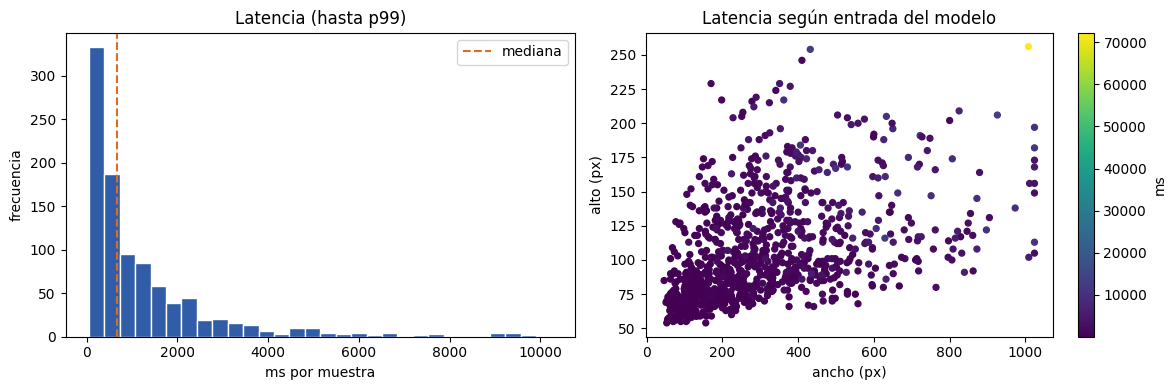

Gráfica: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\benchmark_posformer_crohme_2014.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4)); display_limit = np.percentile(valid['time_ms'], 99)
axes[0].hist(valid.loc[valid['time_ms'] <= display_limit, 'time_ms'], bins=30, color='#315da8', edgecolor='white'); axes[0].axvline(summary['latency_median_ms'], color='#dd6b20', linestyle='--', label='mediana')
axes[0].set(title='Latencia (hasta p99)', xlabel='ms por muestra', ylabel='frecuencia'); axes[0].legend()
scatter = axes[1].scatter(valid['model_width'], valid['model_height'], c=valid['time_ms'], cmap='viridis', s=18); axes[1].set(title='Latencia según entrada del modelo', xlabel='ancho (px)', ylabel='alto (px)'); fig.colorbar(scatter, ax=axes[1], label='ms')
fig.tight_layout(); plot_path = RESULTS_DIR / f'benchmark_posformer_crohme_{YEAR}.png'; fig.savefig(plot_path, dpi=160, bbox_inches='tight'); plt.show(); print('Gráfica:', plot_path)

## Lectura de los resultados

- Exact match y las tasas ≤1/≤2 usan distancia de Levenshtein sobre tokens LaTeX separados por espacios.
- CER micro agrega errores y tokens en todo el conjunto; CER macro promedia el CER de cada expresión.
- Los FLOPs son una estimación de `torch.profiler` y solo cubren los operadores soportados; se miden en una segunda inferencia independiente.
- Latencia y tiempo total contabilizan solo inferencia GPU.
- Pico incremental resta la memoria asignada inmediatamente antes de cada inferencia.
- `model_height` y `model_width` registran el tamaño posterior a la transformación oficial de PosFormer.